# Loan Default Risk with Business Cost Optimization

## Objective
Predict loan default and optimize threshold to minimize business cost.

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.impute import SimpleImputer


## Dataset Loading

In [35]:
df = pd.read_csv("HC_application_train.csv").sample(50000, random_state=42)
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
252818,392541,0,Cash loans,F,N,N,0,76500.0,450000.0,30442.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
185810,315401,0,Cash loans,M,N,N,0,90000.0,180000.0,14350.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
189290,319459,0,Revolving loans,M,Y,Y,0,405000.0,675000.0,33750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
39297,145509,0,Cash loans,F,Y,Y,1,135000.0,521280.0,31630.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,7.0
92015,206854,0,Cash loans,M,N,N,0,112500.0,640080.0,24259.5,...,0,0,0,0,0.0,0.0,1.0,0.0,0.0,2.0


- Handling missing values

In [36]:
missing = df.isnull().mean()
df = df.loc[:, missing < 0.5]

## Fill misiing values

In [26]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\infoa\AppData\Local\Temp\ipykernel_26256\597453801.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns
C:\Users\infoa\AppData\Local\Temp\ipykernel_26256\597453801.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 

- data encoding and Model train

In [39]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

In [40]:
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

X = pd.DataFrame(X)

## Traing and testing split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression

In [42]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\infoa\miniconda3\envs\bank\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predicting Model

In [43]:
y_prob = model.predict_proba(X_test)[:,1]

In [44]:
cost_fp = 1
cost_fn = 5

thresholds = np.arange(0.1,0.9,0.05)
costs = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_cost = (fp*cost_fp) + (fn*cost_fn)
    costs.append(total_cost)

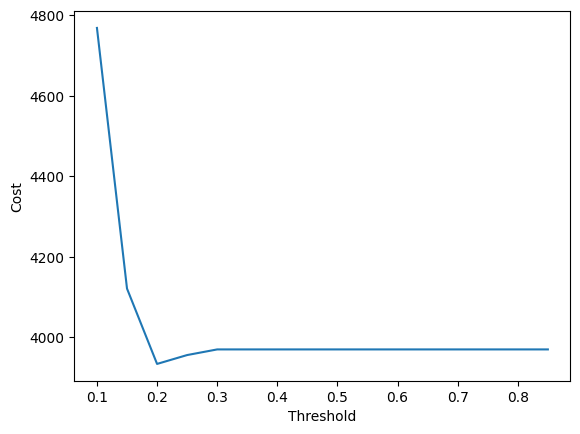

In [45]:
plt.plot(thresholds, costs)
plt.xlabel("Threshold")
plt.ylabel("Cost")
plt.show()

In [46]:
best_threshold = thresholds[np.argmin(costs)]
print("Best Threshold:", best_threshold)

Best Threshold: 0.20000000000000004


In [47]:
y_pred_final = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      9206
           1       0.19      0.06      0.09       794

    accuracy                           0.91     10000
   macro avg       0.56      0.52      0.52     10000
weighted avg       0.87      0.91      0.88     10000



## Conclusion

In this project, we developed a machine learning model to predict the likelihood of loan default using the Home Credit dataset.

After performing data cleaning, handling missing values, and encoding categorical features, a Logistic Regression model was trained to estimate default probabilities.

A key highlight of this project is the use of **business cost optimization** instead of relying on the default classification threshold (0.5). By assigning different costs to false positives and false negatives, we identified an optimal threshold that minimizes overall financial loss.

